### Práctica

Puedes utilizar este notebook para analisar el dataset propuesto

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path



In [4]:
df = pd.read_csv('../data/raw/p4ds_cadenas_unificadas_2025.csv')

In [5]:
df.head()

,Periodo,Grupo,Producto,Super,Precio
0,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto,"80,00"
1,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Devoto Express,"99,00"
2,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Disco,"99,00"
3,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Ta - Ta,"95,00"
4,Abr25,Alimentos y bebidas,Aceite de girasol Marca Propia Envase 900 cc,Tienda Inglesa,"97,00"


Filas: 26834
Columnas: 5
<class 'pandas.DataFrame'>
RangeIndex: 26834 entries, 0 to 26833
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Periodo   26834 non-null  str  
 1   Grupo     26671 non-null  str  
 2   Producto  26812 non-null  str  
 3   Super     24237 non-null  str  
 4   Precio    26401 non-null  str  
dtypes: str(5)
memory usage: 3.0 MB
Filas duplicadas: 1625


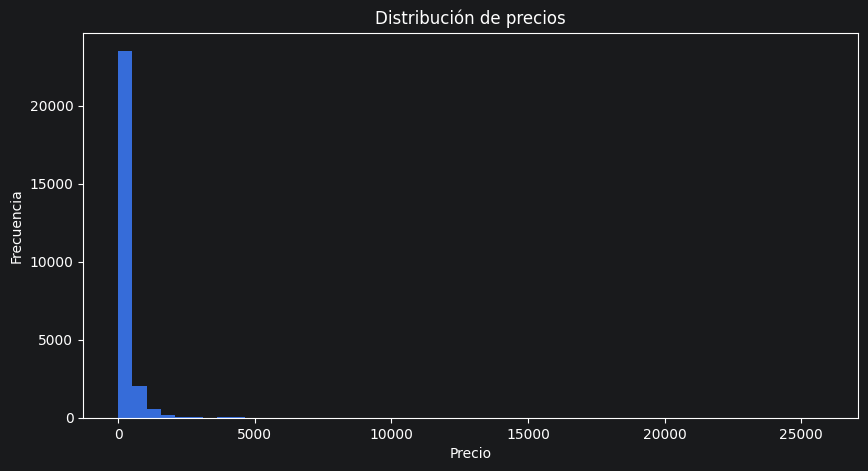

<Figure size 1000x500 with 0 Axes>

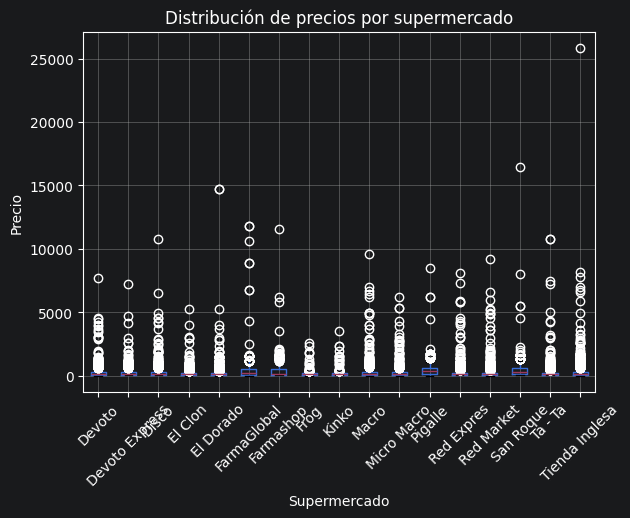

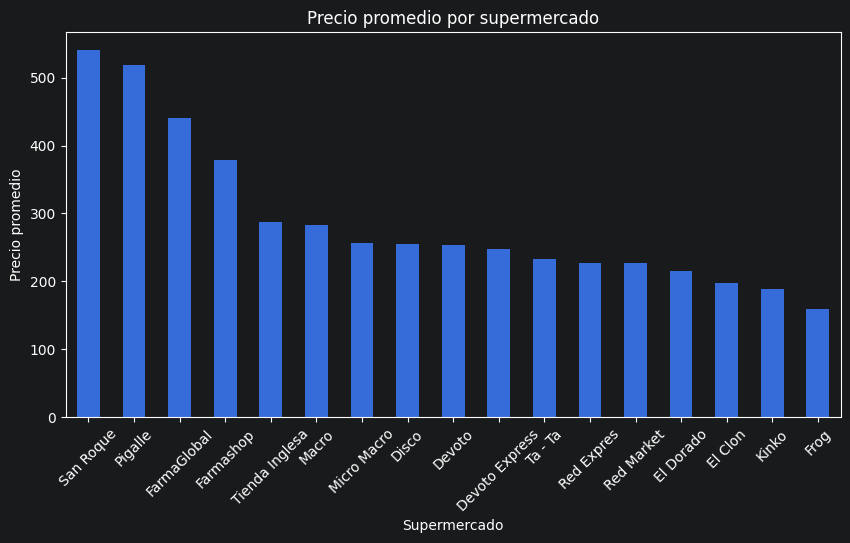

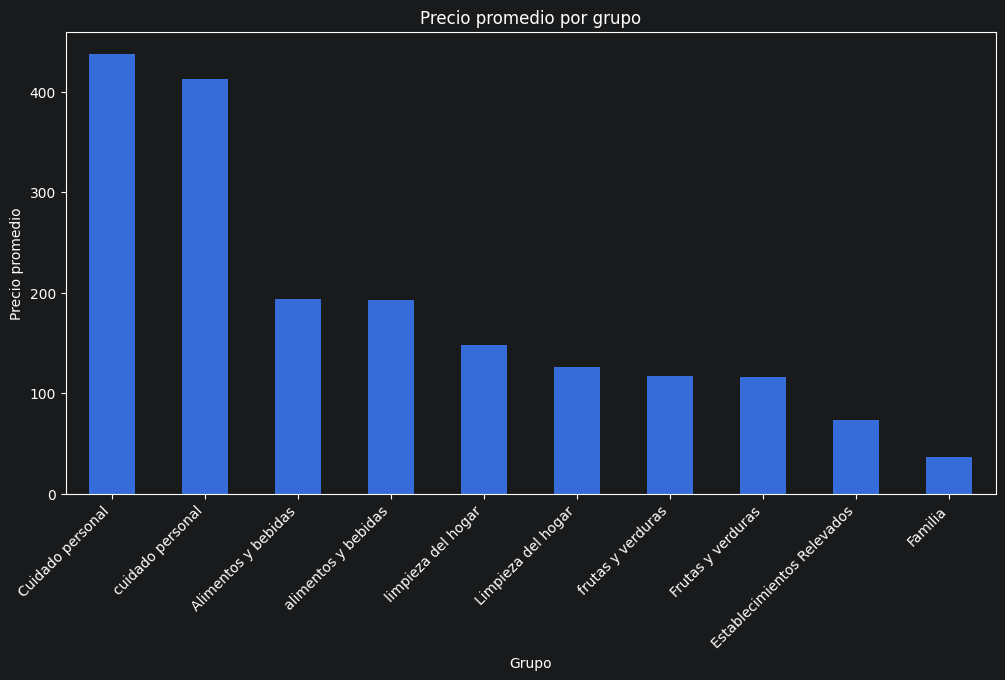

Super,Devoto,Devoto Express,Disco,El Clon,El Dorado,FarmaGlobal,Farmashop,Frog,Kinko,Macro,Micro Macro,Pigalle,Red Expres,Red Market,San Roque,Ta - Ta,Tienda Inglesa,diferencia_max_min
Producto,,,,,,,,,,,,,,,,,,
Protector solar SPF 50 Eucerin 150 ml.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"1,621.00",NaN,NaN,NaN,NaN,"7,224.00","5,603.00"
panales para ninos comun Babysec (48 unidades),"1,133.00",NaN,"4,316.00",989.00,974.00,"1,184.50","4,628.00",NaN,NaN,"1,045.65",NaN,NaN,"1,017.00","1,060.00","1,119.00","1,085.00","1,157.00","3,654.00"
"Crema Facial Revitalift Filler Dia, 50 ml.",NaN,NaN,NaN,NaN,"3,503.00","1,598.20","1,583.00",NaN,NaN,"1,593.65",NaN,NaN,NaN,NaN,NaN,839.00,"1,582.00","2,664.00"
protector solar spf 50 Hawaiian tropic (240 ml.),"1,106.00",NaN,"1,106.00",NaN,NaN,"1,156.50","1,055.00",NaN,NaN,NaN,NaN,"1,055.00","1,058.00","3,680.00","1,030.00",NaN,"1,139.00","2,650.00"
chorizo suelto Centenario-extra (1 kg.),"3,076.67",NaN,749.00,NaN,NaN,NaN,NaN,NaN,NaN,653.20,653.20,NaN,NaN,"2,060.00",NaN,639.00,654.50,"2,437.67"
perfume comun Bebe & co. (120 ml.),676.00,NaN,676.00,NaN,NaN,738.95,681.00,NaN,NaN,735.70,794.50,655.00,640.50,599.00,745.00,"3,000.00",673.50,"2,401.00"
"Pañales Babysec Premium Extra Extra Grande, 48 us.","1,074.91","1,163.65","1,074.50",967.00,950.60,"2,961.28","1,174.00",NaN,NaN,"1,027.30",NaN,NaN,"1,033.30","1,057.35","1,123.00","2,630.69","1,091.00","2,010.68"
"Pañales Huggies Primeros 100 Dias Pequeño, 40 us.",634.50,672.33,639.33,NaN,726.60,"2,189.06",736.90,NaN,NaN,"1,578.10","1,131.96",625.14,671.50,727.30,753.10,630.00,"1,232.73","1,563.92"
repelente de mosquitos aerosol Off! (170 cm3),429.00,NaN,"1,684.00",289.00,353.00,483.90,465.50,NaN,NaN,399.50,418.75,452.00,383.00,405.50,"1,824.00",349.00,376.00,"1,535.00"


In [6]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

# Vista general
df.head()

# Tamaño y columnas
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.columns

# Tipos de datos y nulos
df.info()

# Limpieza básica del precio
df['Precio'] = (
    df['Precio']
    .astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# Resumen estadístico
df.describe(include='all')

# Valores nulos
nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0]

# Duplicados
print("Filas duplicadas:", df.duplicated().sum())

# Cantidad de valores únicos por columna
df.nunique().sort_values(ascending=False)

# Frecuencia por supermercado
df['Super'].value_counts()

# Frecuencia por grupo
df['Grupo'].value_counts()

# Frecuencia por periodo
df['Periodo'].value_counts().sort_index()

# Precio promedio por supermercado
df.groupby('Super')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Precio promedio por grupo
df.groupby('Grupo')['Precio'].agg(['count', 'mean', 'median', 'min', 'max']).sort_values('mean', ascending=False)

# Productos más caros en promedio
df.groupby('Producto')['Precio'].mean().sort_values(ascending=False).head(20)

# Productos más baratos en promedio
df.groupby('Producto')['Precio'].mean().sort_values().head(20)

# Histograma de precios
plt.figure(figsize=(10, 5))
plt.hist(df['Precio'], bins=50)
plt.title('Distribución de precios')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot de precios por supermercado
plt.figure(figsize=(10, 5))
df.boxplot(column='Precio', by='Super', rot=45)
plt.title('Distribución de precios por supermercado')
plt.suptitle('')
plt.xlabel('Supermercado')
plt.ylabel('Precio')
plt.show()

# Precio promedio por supermercado
precio_super = df.groupby('Super')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
precio_super.plot(kind='bar')
plt.title('Precio promedio por supermercado')
plt.xlabel('Supermercado')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45)
plt.show()

# Precio promedio por grupo
precio_grupo = df.groupby('Grupo')['Precio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
precio_grupo.plot(kind='bar')
plt.title('Precio promedio por grupo')
plt.xlabel('Grupo')
plt.ylabel('Precio promedio')
plt.xticks(rotation=45, ha='right')
plt.show()

# Comparación supermercado vs grupo
tabla_super_grupo = pd.pivot_table(
    df,
    values='Precio',
    index='Grupo',
    columns='Super',
    aggfunc='mean'
)

tabla_super_grupo

# Diferencia entre supermercados por producto
comparacion_productos = pd.pivot_table(
    df,
    values='Precio',
    index='Producto',
    columns='Super',
    aggfunc='mean'
)

comparacion_productos['diferencia_max_min'] = comparacion_productos.max(axis=1) - comparacion_productos.min(axis=1)

comparacion_productos.sort_values('diferencia_max_min', ascending=False).head(20)


In [10]:

# Crear carpeta si no existe
processed_path = Path('../data/processed')
processed_path.mkdir(parents=True, exist_ok=True)

# Guardar como Excel
df.to_excel(processed_path / 'cadenas_unificadas_2025_procesado.xlsx', index=False)